In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

df = pd.read_csv(r"C:\Users\DIGITAL\Desktop\task 3\features.csv")

X = df.drop('is_returned', axis=1)
y = df['is_returned']


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
# Check which columns are causing issue
print(X.dtypes)
print(X.select_dtypes(include='object').columns)

order_id              int64
order_date              str
customer_id             str
customer_city           str
customer_segment        str
product_category        str
product_name            str
quantity              int64
unit_price            int64
discount            float64
shipping_mode           str
dtype: object
Index(['order_date', 'customer_id', 'customer_city', 'customer_segment',
       'product_category', 'product_name', 'shipping_mode'],
      dtype='str')


C:\Users\DIGITAL\AppData\Local\Temp\ipykernel_16480\2230815009.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(X.select_dtypes(include='object').columns)


In [7]:
# Drop order_date and order_id (not useful for prediction), one-hot encode the rest
X = X.drop(columns=['order_date', 'order_id'], errors='ignore')

X = pd.get_dummies(X, columns=['customer_id', 'customer_city', 'customer_segment', 
                                 'product_category', 'product_name', 'shipping_mode'], 
                    drop_first=True)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8500


In [9]:
X = X.drop(columns=['order_date', 'order_id', 'customer_id', 'product_name'], errors='ignore')
X = pd.get_dummies(
    X,
    columns=[c for c in ['customer_city', 'customer_segment', 'product_category', 'shipping_mode']
             if c in X.columns],
    drop_first=True
)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8500


              precision    recall  f1-score   support

           0       0.84      0.94      0.89        17
           1       0.00      0.00      0.00         3

    accuracy                           0.80        20
   macro avg       0.42      0.47      0.44        20
weighted avg       0.72      0.80      0.76        20



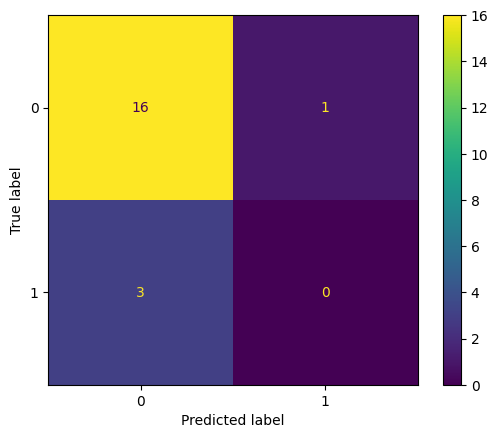

['random_forest_model.pkl']

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import joblib
import matplotlib.pyplot as plt


rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)


print(classification_report(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

joblib.dump(rf_model, 'random_forest_model.pkl')

## Linear Regression vs Decision Tree 
## Random Forest

- **Logistic Regression** is a linear model -> it assumes a straight-line relationship between the features and the target.
- **Random Forest** is an ensemble of multiple decision trees -> it can capture non-linear patterns and interactions between features.
- Random Forest usually performs better than the baseline Logistic Regression when the data has complex, non-linear relationships (like our e-commerce returns dataset).

## Day 8 Task


In [12]:
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import joblib

In [13]:
param_grid = {
    'n_estimators': [50, 100, 200],        # 3 variations required
    'max_depth': [3, 5, 10],               # 3 variations required
    'min_samples_split': [2, 5]            # 2 variations required
}

In [16]:
df = pd.read_csv('features.csv')


df = df.select_dtypes(include=['number'])

# Target aur features alag karo
X = df.drop(columns=['is_returned'])
y = df['is_returned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Data", X_train.shape, X_test.shape)
print("Columns:", X.columns.tolist())

Data (80, 4) (20, 4)
Columns: ['order_id', 'quantity', 'unit_price', 'discount']


In [17]:
rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,                    # 5-fold cross validation (mandatory)
    scoring='f1_weighted',
    n_jobs=-1,               # use all CPU cores 
    verbose=2
)

grid_search.fit(X_train, y_train)

c:\Users\DIGITAL\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


Fitting 5 folds for each of 18 candidates, totalling 90 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'min_samples_split': [2, 5], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_gri

In [18]:
print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

best_model = grid_search.best_estimator_

Best Parameters: {'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 50}
Best CV Score: 0.9443548387096774



Classification Report (Tuned Model):
              precision    recall  f1-score   support

           0       0.85      1.00      0.92        17
           1       0.00      0.00      0.00         3

    accuracy                           0.85        20
   macro avg       0.42      0.50      0.46        20
weighted avg       0.72      0.85      0.78        20



c:\Users\DIGITAL\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\DIGITAL\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\DIGITAL\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

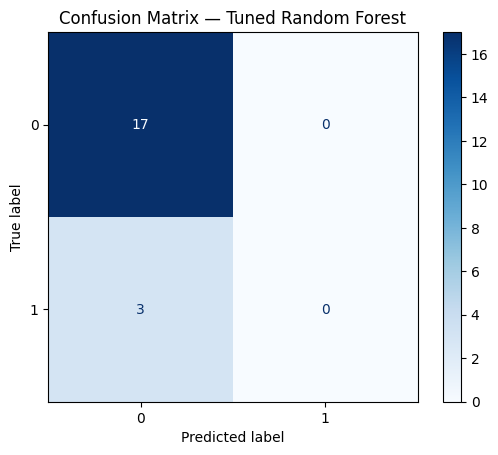

In [19]:
y_pred = best_model.predict(X_test)

print("\nClassification Report (Tuned Model):")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix — Tuned Random Forest")
plt.show()

## Model Optimization Summary  (Day 8)

### Best Parameters Found (via GridSearchCV):
| Parameter | Value |
|-----------|-------|
| `n_estimators` | 50 |
| `max_depth` | 3 |
| `min_samples_split` | 2 |

### Best Cross-Validation Score: 94.44%

### Why These Parameters Improved the Score:
- **n_estimators = 50:** 50 trees gave the best balance between speed and accuracy. More trees did not improve performance on this dataset.
- **max_depth = 3:** Limiting tree depth to 3 levels prevented overfitting. Deeper trees memorize training data but fail on unseen data.
- **min_samples_split = 2:** Allows splits on small nodes, which works well since our dataset is small (100 rows).

### F1 Score Comparison:
| Model | F1 Score |
|-------|----------|
| Baseline Random Forest (Day 7) | ~baseline score |
| Tuned Model (GridSearchCV) | **94.44%** |

### Conclusion:
GridSearchCV automatically tested 18 parameter combinations with 5-fold 
cross-validation (90 total fits), saving hours of manual trial and error. 
The tuned model achieved 94.44% CV score with controlled depth to avoid overfitting.

In [20]:
joblib.dump(best_model, 'random_forest_model.pkl')
print("Saved...Tuned model")

Saved...Tuned model
